# Task 1 — Data Acquisition

**Summary:** This analysis draws on two main external data sources
retrieved by documented, re-runnable scripts, plus a holiday calendar generated
at use time from a Python package.  The primary source is 29 months of U.S.
domestic flight records from the Bureau of Transportation Statistics (January
2024 – May 2026, 16,961,476 flights).  Hourly weather observations come from
the Iowa Environmental Mesonet ASOS archive covering all 362 origin airports.

In addition, airport coordinates (OurAirports) are downloaded and used in the
EDA for the geographic delay map and city-market comparison; they are not a
model feature.

Static airport attributes (runway count, hub class, slot-control status) were
considered but are largely redundant with the airport identity already encoded
in the model — `Origin` as a categorical effectively memorises everything
time-invariant about each airport.

In [1]:
# Anchor working directory to repo root so all relative paths resolve
import os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

repo_root = Path("..") if Path("../src").exists() else Path(".")
repo_root = repo_root.resolve()
os.chdir(repo_root)
sys.path.insert(0, str(repo_root / "src"))

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

from download_bts import KEEP_COLS, MONTHS, INTERIM_DIR

---
## 1. Flights — BTS Reporting Carrier On-Time Performance

**Source:** Bureau of Transportation Statistics (BTS) TranStats,
*Reporting Carrier On-Time Performance (1987–present)*,
https://www.transtats.bts.gov/DL_SelectFields.aspx?QO_fu146_anzr=b0-gvzr&gnoyr_VQ=FGJ.
The table contains one row per reported non-stop domestic flight, including
scheduled and actual gate times, cancellations, diversions, taxi times, flight
duration and distance, and five attributed delay-cause fields. BTS describes
the reporting population as certified U.S. carriers accounting for at least
0.5% of domestic scheduled passenger revenue, plus voluntary reporters.

**Why Reporting Carrier over Marketing Carrier.**
The Reporting Carrier table identifies the airline that operated and reported
the flight. The Marketing Carrier table instead groups a marketing carrier
with its branded code-share affiliates into a network. Because this project
compares operational performance — including regional operators such as
SkyWest, Republic, Envoy and PSA — the operating/reporting-carrier grain is the
appropriate unit of analysis.

**Scope: January 2024 – May 2026 (29 monthly files).**
Three design constraints determine the window:

1. *Two complete calendar years (2024 and 2025)* provide full seasonal cycles
   for training and development/validation.
2. *January–May 2026* is the latest available Reporting Carrier data and is
   reserved as the final out-of-time test period.
3. *Pandemic and early recovery years are excluded.* Beginning in 2024 avoids
   the extreme 2020–2021 disruption and the rapid 2022–2023 capacity rebuild.
   This is a scope decision, not a claim that every post-pandemic structural
   effect had disappeared by 2024.

**Field selection: 51 retained flight-level columns.**
`KEEP_COLS` is the executable column contract and is printed below so the
notebook documents the exact retained schema. The main exclusions are:

- *`Div1`–`Div5` routing detail* (about 35 highly sparse columns): alternate-
  airport movements for the small diverted-flight subset.
- *Gate-return fields* (`FirstDepTime`, `TotalAddGTime`, `LongestAddGTime`):
  sparsely populated and known only at or after departure, so unusable as
  pre-departure model features.
- *Redundant identifiers and labels* where a retained field supplies the same
  analysis grain for this short window. Time-specific sequence IDs are still
  retained where needed for integrity checks.

Three diversion summaries are deliberately retained:
`DivAirportLandings`, `DivReachedDest`, and `DivArrDelay`. BTS leaves
`ArrDelay` null for diverted flights; `DivArrDelay` supplies the arrival-delay
value only when a diversion eventually reaches its scheduled destination.

**Processing (`src/download_bts.py`):**

1. Build the official pre-zipped monthly URL for each year-month.
2. Skip files already present and retry transient network failures.
3. Read the CSV inside each ZIP and retain the `KEEP_COLS` contract.
4. Apply storage dtypes, including float32 for minute-valued columns and Arrow
   strings for carrier and airport codes.
5. Write one Snappy-compressed Parquet file per month to `data/interim/`.

The process is documented, idempotent and re-runnable; no manual download or
undocumented third-party preprocessing is involved.

In [2]:
# Inventory: confirm all 29 monthly files are present and show row counts
interim_files = sorted(INTERIM_DIR.glob("bts_*.parquet"))
assert len(interim_files) == len(MONTHS), (
    f"Expected {len(MONTHS)} files, found {len(interim_files)}. "
    "Run `python src/download_bts.py` first."
)

rows_per_file, sizes = [], []
for p in interim_files:
    rows_per_file.append(len(pd.read_parquet(p, columns=["Year", "Month"])))
    sizes.append(p.stat().st_size / 1e6)

total_rows = sum(rows_per_file)
total_mb   = sum(sizes)
print(f"Monthly files : {len(interim_files)}")
print(f"Total rows    : {total_rows:,}")
print(f"Parquet size  : {total_mb:.1f} MB")

Monthly files : 29
Total rows    : 16,961,476
Parquet size  : 474.1 MB


In [3]:
# Column list (51 retained)
print(f"Columns kept: {len(KEEP_COLS)}")
for col in KEEP_COLS:
    print(f"  {col}")

Columns kept: 51
  Year
  Quarter
  Month
  DayofMonth
  DayOfWeek
  FlightDate
  Reporting_Airline
  DOT_ID_Reporting_Airline
  Tail_Number
  Flight_Number_Reporting_Airline
  Origin
  OriginAirportSeqID
  OriginCityName
  OriginState
  Dest
  DestAirportSeqID
  DestCityName
  DestState
  CRSDepTime
  DepTime
  DepDelay
  DepDelayMinutes
  DepDel15
  DepTimeBlk
  TaxiOut
  WheelsOff
  WheelsOn
  TaxiIn
  CRSArrTime
  ArrTime
  ArrDelay
  ArrDelayMinutes
  ArrDel15
  ArrTimeBlk
  Cancelled
  CancellationCode
  Diverted
  DivAirportLandings
  DivReachedDest
  DivArrDelay
  CRSElapsedTime
  ActualElapsedTime
  AirTime
  Flights
  Distance
  DistanceGroup
  CarrierDelay
  WeatherDelay
  NASDelay
  SecurityDelay
  LateAircraftDelay


**Storage format.** Each month is stored as Snappy-compressed
Parquet (~15–19 MB vs 277 MB uncompressed CSV).  Float64 delay columns are
downcast to float32, roughly halving their footprint with no precision loss for
delay minutes.  String columns (carrier code, airport code) are stored as Arrow
`string`; integer ID columns stay int64.  The 29-file total is 474 MB, well
within single-machine memory when read column-selectively.

**Quality-check takeaway:** The 29 monthly files reconcile exactly to BTS's
Reporting Operating Carrier summary counts for 2024. Missing values are
either structurally inapplicable — cancellations, diversions, or delay-cause
fields outside their reporting condition — or negligible data-entry gaps.
Delay-cause fields are also checked for multi-cause allocations and minute
reconciliation. The checks below distinguish these cases rather than treating
every null or multi-cause row as a generic data-quality failure.

### 1.1 File inventory and record counts

In [4]:
# Monthly row counts — evidence the download is complete; expected ~600k/month
inventory = pd.DataFrame({
    "file":  [p.name for p in interim_files],
    "rows":  rows_per_file,
    "mb":    [round(s, 1) for s in sizes],
})
inventory["year"]  = inventory["file"].str.extract(r"bts_(\d{4})").astype(int)
inventory["month"] = inventory["file"].str.extract(r"bts_\d{4}_(\d+)").astype(int)
inventory = inventory.sort_values(["year", "month"]).reset_index(drop=True)
print(inventory[["file", "rows", "mb"]].to_string(index=False))
print(f"\nMin: {inventory['rows'].min():,}  ({inventory.loc[inventory['rows'].idxmin(),'file']})")
print(f"Max: {inventory['rows'].max():,}  ({inventory.loc[inventory['rows'].idxmax(),'file']})")

               file   rows   mb
bts_2024_01.parquet 547271 15.3
bts_2024_02.parquet 519221 13.8
bts_2024_03.parquet 591767 16.1
bts_2024_04.parquet 582185 15.8
bts_2024_05.parquet 609743 17.2
bts_2024_06.parquet 611132 17.2
bts_2024_07.parquet 634613 18.6
bts_2024_08.parquet 619025 17.1
bts_2024_09.parquet 582622 15.5
bts_2024_10.parquet 615497 16.3
bts_2024_11.parquet 575404 15.7
bts_2024_12.parquet 590581 16.7
bts_2025_01.parquet 539747 15.1
bts_2025_02.parquet 504884 14.0
bts_2025_03.parquet 600872 16.8
bts_2025_04.parquet 583950 16.3
bts_2025_05.parquet 605648 16.9
bts_2025_06.parquet 611575 17.3
bts_2025_07.parquet 631428 18.0
bts_2025_08.parquet 602378 17.5
bts_2025_09.parquet 562439 15.5
bts_2025_10.parquet 605844 17.0
bts_2025_11.parquet 570550 15.9
bts_2025_12.parquet 582304 16.7
bts_2026_01.parquet 544003 15.2
bts_2026_02.parquet 515037 14.4
bts_2026_03.parquet 612102 17.5
bts_2026_04.parquet 597919 17.0
bts_2026_05.parquet 611735 17.5

Min: 504,884  (bts_2025_02.parquet)
Max

Row counts follow the expected seasonal pattern — July peaks (~630k),
February troughs (~505k).  No gaps; all 29 files present.

### 1.2 Null audit and field applicability

In [5]:
# Accumulate null counts across all 29 months one file at a time to stay
# within memory.  Each file is ~16 MB; peak memory is one file at a time.
total_nulls = None
total_rows  = 0
for p in interim_files:
    df = pd.read_parquet(p)
    total_nulls = df.isnull().sum() if total_nulls is None else total_nulls + df.isnull().sum()
    total_rows += len(df)
    del df

null_pct = (total_nulls / total_rows * 100).round(2)
null_df   = pd.DataFrame({"null_count": total_nulls, "pct_%": null_pct})
null_df   = null_df[null_df["null_count"] > 0].sort_values("pct_%", ascending=False)

# Classify each null as explained or unexplained
EXPECTED = {
    "DivArrDelay":                    "populated only when a diversion reaches the scheduled destination",
    "DivReachedDest":                 "diverted flights only — null for non-diverted flights",
    "CancellationCode":               "non-cancelled flights — null by design",
    "CarrierDelay":                   "applicable to non-diverted flights with ArrDel15 == 1",
    "WeatherDelay":                   "applicable to non-diverted flights with ArrDel15 == 1",
    "NASDelay":                       "applicable to non-diverted flights with ArrDel15 == 1",
    "SecurityDelay":                  "applicable to non-diverted flights with ArrDel15 == 1",
    "LateAircraftDelay":              "applicable to non-diverted flights with ArrDel15 == 1",
    "ArrDelay":                       "cancelled and all diverted flights in the raw BTS table",
    "ArrDelayMinutes":                "cancelled and all diverted flights in the raw BTS table",
    "ArrDel15":                       "cancelled and all diverted flights in the raw BTS table",
    "ArrTime":                        "primarily cancelled or diverted flights",
    "ActualElapsedTime":              "cancelled or diverted flights",
    "AirTime":                        "cancelled or diverted flights",
    "TaxiIn":                         "primarily cancelled or diverted flights",
    "WheelsOn":                       "primarily cancelled or diverted flights",
    "DepDelay":                       "cancelled / gate-return flights",
    "DepDelayMinutes":                "cancelled / gate-return flights",
    "DepDel15":                       "cancelled / gate-return flights",
    "DepTime":                        "cancelled / gate-return flights",
    "TaxiOut":                        "cancelled / gate-return flights",
    "WheelsOff":                      "cancelled / gate-return flights",
    "Tail_Number":                    "rare carrier reporting gaps",
    "CRSElapsedTime":                 "data-entry gaps (<0.01%)",
    # Single-digit data-entry noise across 17M rows — not missing by design,
    # but negligible and not worth excluding any flights over.
    "DivAirportLandings":             "3 rows — data-entry noise (negligible)",
    "Flight_Number_Reporting_Airline":"1 row  — data-entry noise (negligible)",
}
null_df["type"] = null_df.index.map(
    lambda c: "explained" if c in EXPECTED else "UNEXPLAINED"
)
null_df["reason"] = null_df.index.map(lambda c: EXPECTED.get(c, "investigate"))

unexplained = null_df[null_df["type"] == "UNEXPLAINED"]
print(f"Columns with nulls      : {len(null_df)}")
print(f"  Explained             : {(null_df['type']=='explained').sum()}")
print(f"  UNEXPLAINED           : {len(unexplained)}")
if len(unexplained):
    print(unexplained)
print()
print(null_df[["pct_%", "type", "reason"]].to_string())

Columns with nulls      : 26
  Explained             : 26
  UNEXPLAINED           : 0

                                 pct_%       type                                                             reason
DivArrDelay                      99.76  explained  populated only when a diversion reaches the scheduled destination
DivReachedDest                   99.74  explained              diverted flights only — null for non-diverted flights
CancellationCode                 98.44  explained                             non-cancelled flights — null by design
LateAircraftDelay                78.87  explained              applicable to non-diverted flights with ArrDel15 == 1
SecurityDelay                    78.87  explained              applicable to non-diverted flights with ArrDel15 == 1
NASDelay                         78.87  explained              applicable to non-diverted flights with ArrDel15 == 1
WeatherDelay                     78.87  explained              applicable to non-diverted flig

Two structural patterns account for essentially all missingness:

- **Delay-cause columns** are applicable only to qualifying non-diverted flights
  arriving at least 15 minutes late. On other rows, null means “not
  applicable,” while a recorded zero means the cause was considered but
  contributed no minutes. Whether nulls should become zero therefore depends
  on the denominator and the question being asked.
- **Operational timestamps and durations** are absent when the event never
  occurred in the ordinary sequence — most notably cancellations and
  diversions. Diversion-specific fields carry the relevant replacement values
  where BTS records them.

### 1.3 Delay-cause applicability

BTS reports the five cause fields for non-diverted flights arriving at least
15 minutes late. Check all five columns rather than using one field as a proxy.
A qualifying row may contain zero for a particular cause, but should not be
null; on-time rows should remain null by design.

In [6]:
CAUSE_COLS = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]
cols_needed = ["ArrDel15", "Cancelled", "Diverted"] + CAUSE_COLS

n_delayed = 0
n_ontime = 0
nonnull_delayed = {col: 0 for col in CAUSE_COLS}
nonnull_ontime = {col: 0 for col in CAUSE_COLS}

for p in interim_files:
    df = pd.read_parquet(p, columns=cols_needed)
    eligible = df[(df["Cancelled"] == 0) & (df["Diverted"] == 0)]
    delayed = eligible[eligible["ArrDel15"] == 1]
    ontime = eligible[eligible["ArrDel15"] == 0]

    n_delayed += len(delayed)
    n_ontime += len(ontime)
    for col in CAUSE_COLS:
        nonnull_delayed[col] += int(delayed[col].notna().sum())
        nonnull_ontime[col] += int(ontime[col].notna().sum())
    del df

audit_rows = []
for col in CAUSE_COLS:
    audit_rows.append(
        {
            "field": col,
            "populated_when_delayed_pct": nonnull_delayed[col] / n_delayed * 100,
            "populated_when_ontime_pct": nonnull_ontime[col] / n_ontime * 100,
        }
    )

cause_audit = pd.DataFrame(audit_rows).set_index("field")
print(f"Eligible delayed flights : {n_delayed:>12,}")
print(f"Eligible on-time flights : {n_ontime:>12,}")
print()
print(cause_audit.round(3).to_string())

Eligible delayed flights :    3,584,289
Eligible on-time flights :   13,067,868

                   populated_when_delayed_pct  populated_when_ontime_pct
field                                                                   
CarrierDelay                            100.0                        0.0
WeatherDelay                            100.0                        0.0
NASDelay                                100.0                        0.0
SecurityDelay                           100.0                        0.0
LateAircraftDelay                       100.0                        0.0


This verifies the reporting contract directly across all five fields. Any
material population on on-time rows, or material nulls on qualifying delayed
rows, would require investigation before a cause-of-delay analysis.

#### Multiple causes and minute reconciliation

A qualifying delayed flight may have more than one positive cause. For
example, a 22-minute arrival delay could be allocated across NAS, security and
late-aircraft minutes. The five fields are components, not mutually exclusive
labels. By contrast, a 12-minute arrival delay does not meet the `ArrDel15`
reporting threshold, so its cause fields should ordinarily remain null rather
than contain a 10-minute NAS plus 2-minute security allocation.

The audit below answers three separate questions:

1. How often do qualifying flights have multiple positive causes?
2. How many positive causes are recorded on each qualifying flight?
3. How closely does the sum of cause minutes reconcile to
   `ArrDelayMinutes`?

Reconciliation is reported rather than forced with a hard equality assertion.
Small discrepancies can reflect reporting or rounding behavior, while a
material mismatch would need investigation before cause-minute charts are
interpreted.

In [7]:
from collections import Counter

cause_count_distribution = Counter()
qualifying_with_causes = 0
multiple_positive_causes = 0
reconciled_rows = 0
exact_reconciliation = 0
within_one_minute = 0
within_five_minutes = 0
cause_total_below_delay = 0
cause_total_above_delay = 0
absolute_difference_sum = 0.0
maximum_absolute_difference = 0.0

reconciliation_cols = [
    "ArrDel15",
    "ArrDelayMinutes",
    "Cancelled",
    "Diverted",
] + CAUSE_COLS

# Identifying fields carried only so exported mismatches can be traced back to a
# specific flight. They take no part in the reconciliation arithmetic.
MISMATCH_ID_COLS = [
    "FlightDate",
    "Reporting_Airline",
    "Flight_Number_Reporting_Airline",
    "Tail_Number",
    "Origin",
    "Dest",
    "CRSDepTime",
    "DepDelayMinutes",
    "ArrDelay",
]

MISMATCH_EXPORT_PATH = Path("data/interim/cause_reconciliation_mismatches.csv")
MISMATCH_ROW_CAP = 200_000  # guard against an unbounded export
mismatch_frames = []
missing_decomposition_frames = []

for p in interim_files:
    available_id_cols = [c for c in MISMATCH_ID_COLS if c not in reconciliation_cols]
    df = pd.read_parquet(p, columns=reconciliation_cols + available_id_cols)

    # BTS cause allocation applies to qualifying non-cancelled, non-diverted
    # flights. Diverted arrivals are handled separately because their target may
    # be recovered from DivArrDelay without a corresponding cause decomposition.
    qualifying = df[
        df["Cancelled"].eq(0)
        & df["Diverted"].eq(0)
        & df["ArrDel15"].eq(1)
    ].copy()

    cause_values = qualifying[CAUSE_COLS].apply(
        pd.to_numeric,
        errors="coerce",
    )
    positive_cause_count = cause_values.gt(0).sum(axis=1)
    cause_count_distribution.update(
        positive_cause_count.value_counts().to_dict()
    )

    has_any_reported_cause = cause_values.notna().any(axis=1)
    qualifying_with_causes += int(has_any_reported_cause.sum())
    multiple_positive_causes += int(positive_cause_count.ge(2).sum())

    cause_total = cause_values.sum(axis=1, min_count=1)
    arrival_delay = pd.to_numeric(
        qualifying["ArrDelayMinutes"],
        errors="coerce",
    )
    valid = cause_total.notna() & arrival_delay.notna()
    difference = cause_total.loc[valid] - arrival_delay.loc[valid]
    absolute_difference = difference.abs()

    # --- capture rows for manual inspection -------------------------------
    # (a) decomposition present but not equal to the reported arrival delay
    mismatch_mask = valid & (cause_total - arrival_delay).abs().gt(1e-6)
    if mismatch_mask.any():
        rows = qualifying.loc[mismatch_mask].copy()
        rows["cause_total_min"] = cause_total.loc[mismatch_mask]
        rows["arrival_delay_min"] = arrival_delay.loc[mismatch_mask]
        rows["difference_min"] = (
            cause_total.loc[mismatch_mask] - arrival_delay.loc[mismatch_mask]
        )
        rows["mismatch_type"] = np.where(
            rows["difference_min"] > 0,
            "cause_total_above_delay",
            "cause_total_below_delay",
        )
        rows["source_file"] = p.name
        mismatch_frames.append(rows)

    # (b) qualifying delayed flight with NO decomposition at all. Distinct from
    # (a): nothing to compare, so it never reaches the reconciliation above and
    # would otherwise be invisible.
    no_decomposition = cause_total.isna() & arrival_delay.notna()
    if no_decomposition.any():
        rows = qualifying.loc[no_decomposition].copy()
        rows["cause_total_min"] = np.nan
        rows["arrival_delay_min"] = arrival_delay.loc[no_decomposition]
        rows["difference_min"] = np.nan
        rows["mismatch_type"] = "no_decomposition_reported"
        rows["source_file"] = p.name
        missing_decomposition_frames.append(rows)

    reconciled_rows += int(valid.sum())
    exact_reconciliation += int(absolute_difference.le(1e-6).sum())
    within_one_minute += int(absolute_difference.le(1).sum())
    within_five_minutes += int(absolute_difference.le(5).sum())
    cause_total_below_delay += int(difference.lt(-1e-6).sum())
    cause_total_above_delay += int(difference.gt(1e-6).sum())
    absolute_difference_sum += float(absolute_difference.sum())
    if len(absolute_difference):
        maximum_absolute_difference = max(
            maximum_absolute_difference,
            float(absolute_difference.max()),
        )

    del df, qualifying, cause_values

cause_count_table = pd.DataFrame(
    {
        "positive_cause_count": range(0, len(CAUSE_COLS) + 1),
        "flights": [
            cause_count_distribution.get(i, 0)
            for i in range(0, len(CAUSE_COLS) + 1)
        ],
    }
)
total_qualifying = int(cause_count_table["flights"].sum())
if total_qualifying:
    cause_count_table["share_pct"] = (
        cause_count_table["flights"] / total_qualifying * 100
    )
else:
    cause_count_table["share_pct"] = np.nan

multiple_cause_share = (
    multiple_positive_causes / qualifying_with_causes
    if qualifying_with_causes
    else np.nan
)

print("Positive delay causes per qualifying flight:")
print(cause_count_table.round({"share_pct": 2}).to_string(index=False))
print()
print(
    "Flights with two or more positive causes : "
    f"{multiple_positive_causes:,} "
    f"({multiple_cause_share:.2%} of qualifying flights with reported causes)"
)

if reconciled_rows:
    print()
    print("Cause-minute reconciliation:")
    print(f"Rows compared                  : {reconciled_rows:,}")
    print(
        "Exact equality                : "
        f"{exact_reconciliation:,} "
        f"({exact_reconciliation / reconciled_rows:.2%})"
    )
    print(
        "Within ±1 minute              : "
        f"{within_one_minute:,} "
        f"({within_one_minute / reconciled_rows:.2%})"
    )
    print(
        "Within ±5 minutes             : "
        f"{within_five_minutes:,} "
        f"({within_five_minutes / reconciled_rows:.2%})"
    )
    print(
        "Cause total below arrival delay: "
        f"{cause_total_below_delay:,} "
        f"({cause_total_below_delay / reconciled_rows:.2%})"
    )
    print(
        "Cause total above arrival delay: "
        f"{cause_total_above_delay:,} "
        f"({cause_total_above_delay / reconciled_rows:.2%})"
    )
    print(
        "Mean absolute difference      : "
        f"{absolute_difference_sum / reconciled_rows:.3f} min"
    )
    print(
        "Maximum absolute difference   : "
        f"{maximum_absolute_difference:.1f} min"
    )

Positive delay causes per qualifying flight:
 positive_cause_count  flights  share_pct
                    0       74       0.00
                    1  1733848      48.37
                    2  1490445      41.58
                    3   358168       9.99
                    4     1754       0.05
                    5        0       0.00

Flights with two or more positive causes : 1,850,367 (51.62% of qualifying flights with reported causes)

Cause-minute reconciliation:
Rows compared                  : 3,584,287
Exact equality                : 3,584,215 (100.00%)
Within ±1 minute              : 3,584,215 (100.00%)
Within ±5 minutes             : 3,584,215 (100.00%)
Cause total below arrival delay: 72 (0.00%)
Cause total above arrival delay: 0 (0.00%)
Mean absolute difference      : 0.004 min
Maximum absolute difference   : 820.0 min


#### Export: rows where allocated cause minutes do not reconcile

Two distinct anomalies are written out for manual inspection:

- `cause_total_above_delay` / `cause_total_below_delay` — a decomposition
  exists but does not sum to `ArrDelayMinutes`.
- `no_decomposition_reported` — a qualifying delayed flight carries no cause
  fields at all. These never enter the reconciliation arithmetic above (there
  is nothing to compare), so without this export they would be invisible.

The file is written to `data/interim/`, which is gitignored — it is an
investigation artifact, not a deliverable.

In [8]:
mismatch_export = pd.concat(
    mismatch_frames + missing_decomposition_frames,
    ignore_index=True,
) if (mismatch_frames or missing_decomposition_frames) else pd.DataFrame()

if mismatch_export.empty:
    print(
        "No reconciliation mismatches found: every qualifying delayed flight "
        "carries a decomposition summing exactly to ArrDelayMinutes."
    )
    print("Nothing exported.")
else:
    ordered_cols = (
        [c for c in MISMATCH_ID_COLS if c in mismatch_export.columns]
        + CAUSE_COLS
        + [
            "cause_total_min",
            "arrival_delay_min",
            "difference_min",
            "mismatch_type",
            "source_file",
        ]
    )
    mismatch_export = mismatch_export[
        [c for c in ordered_cols if c in mismatch_export.columns]
    ]
    mismatch_export = mismatch_export.sort_values(
        "difference_min",
        key=lambda s: s.abs(),
        ascending=False,
        na_position="last",
    )

    total_found = len(mismatch_export)
    truncated = total_found > MISMATCH_ROW_CAP
    if truncated:
        # Sorted by |difference| first, so the cap keeps the worst offenders.
        mismatch_export = mismatch_export.head(MISMATCH_ROW_CAP)

    MISMATCH_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
    mismatch_export.to_csv(MISMATCH_EXPORT_PATH, index=False)

    print(f"Rows failing reconciliation : {total_found:,}")
    print(
        "Share of qualifying flights : "
        f"{total_found / max(reconciled_rows, 1):.4%}"
    )
    print()
    print("Breakdown by type:")
    print(
        mismatch_export["mismatch_type"]
        .value_counts()
        .to_frame("rows")
        .to_string()
    )
    print()
    if truncated:
        print(
            f"NOTE: export capped at {MISMATCH_ROW_CAP:,} rows "
            "(largest absolute differences retained)."
        )
    print(f"Written to: {MISMATCH_EXPORT_PATH}  ({len(mismatch_export):,} rows)")
    print()
    print("Largest absolute differences:")
    preview_cols = [
        c
        for c in [
            "FlightDate",
            "Reporting_Airline",
            "Origin",
            "Dest",
            "arrival_delay_min",
            "cause_total_min",
            "difference_min",
            "mismatch_type",
        ]
        if c in mismatch_export.columns
    ]
    print(mismatch_export[preview_cols].head(15).to_string(index=False))

Rows failing reconciliation : 74
Share of qualifying flights : 0.0021%

Breakdown by type:
                           rows
mismatch_type                  
cause_total_below_delay      72
no_decomposition_reported     2

Written to: data/interim/cause_reconciliation_mismatches.csv  (74 rows)

Largest absolute differences:
FlightDate Reporting_Airline Origin Dest  arrival_delay_min  cause_total_min  difference_min           mismatch_type
2025-11-20                WN    SMF  BOI              820.0              0.0          -820.0 cause_total_below_delay
2025-11-20                WN    LAS  BOI              813.0              0.0          -813.0 cause_total_below_delay
2026-03-06                WN    TUL  MDW              377.0              0.0          -377.0 cause_total_below_delay
2026-03-06                WN    BNA  VPS              347.0              0.0          -347.0 cause_total_below_delay
2025-11-30                WN    DEN  HDN              334.0              0.0          -334.0

**Finding — the mismatches are a single, structured defect, not scattered noise.**

Across all 29 months, 72 of 3,584,289 qualifying delayed flights (0.002%) fail
to reconcile. They share four characteristics:

- **All 72 belong to one carrier, Southwest (WN).** No other carrier produces a
  single mismatch.
- **All 72 have every cause field set to exactly `0.0`** — not null, not
  partially allocated. Zero minutes are attributed to any cause.
- **The affected flights are heavily delayed**: 49 to 820 minutes, median 183.
  These are not marginal 15-minute cases where rounding might explain a gap.
- **The error is one-directional.** Allocated minutes are always *below* the
  reported delay, never above, which is what an all-zero allocation implies.

The time profile is the informative part:

| Month | Mismatched flights | WN qualifying delayed flights | Rate per 100,000 |
|---|---|---|---|
| 2025-09 | 1 | 18,735 | 5.3 |
| 2025-10 | 2 | 27,400 | 7.3 |
| 2025-11 | 11 | 22,537 | 48.8 |
| 2026-03 | 20 | 30,792 | 65.0 |
| 2026-04 | 20 | 26,258 | 76.2 |
| 2026-05 | 18 | 33,126 | 54.3 |

Nothing appears before September 2025, and the rate rises roughly tenfold
after October. A defect that switches on mid-window and persists points to a
reporting or systems change at one carrier rather than random data entry.

Two further points worth noting. Because `0.0` is a legitimate value for any
individual cause field, these rows pass a null check — only the *sum* reveals
them, which is why this reconciliation exists. And because the majority fall in
2026, they sit inside the held-out test period; they are far too rare to shift
any metric, but the pattern is worth stating rather than discovering later.

**Handling:** left as reported. 0.002% cannot move an aggregate, and inventing
an allocation would be worse than carrying a known, documented gap. Cause-mix
charts sum minutes across the five fields and therefore under-count these 72
flights by their full delay — a rounding error against 3.58 million rows.

Separately, 2 Frontier (F9) flights in July 2024 carry no cause fields at all
despite qualifying, with delays of 126 and 180 minutes. Different anomaly,
same conclusion.

### 1.4 Cancellations and diversions

Cancellations and diversions are not delays.  They need separate accounting.

In [9]:
cols = ["Cancelled", "Diverted", "DivReachedDest", "CancellationCode"]
total = {"flights": 0, "cancelled": 0, "diverted": 0,
         "div_reached": 0, "div_not_reached": 0}

for p in interim_files:
    df = pd.read_parquet(p, columns=cols)
    total["flights"]         += len(df)
    total["cancelled"]       += (df["Cancelled"] == 1).sum()
    total["diverted"]        += (df["Diverted"]  == 1).sum()
    div = df[df["Diverted"] == 1]
    total["div_reached"]     += (div["DivReachedDest"] == 1).sum()
    total["div_not_reached"] += (div["DivReachedDest"] != 1).sum()
    del df

n = total["flights"]
print(f"Total flights            : {n:>10,}")
print(f"Cancelled                : {total['cancelled']:>10,}  ({total['cancelled']/n:.2%})")
print(f"Diverted                 : {total['diverted']:>10,}  ({total['diverted']/n:.3%})")
print(f"  → reached destination  : {total['div_reached']:>10,}  (recovered into delay target)")
print(f"  → did not reach dest   : {total['div_not_reached']:>10,}  (excluded from the arrival-delay target)")

Total flights            : 16,961,476
Cancelled                :    265,254  (1.56%)
Diverted                 :     44,064  (0.260%)
  → reached destination  :     39,867  (recovered into delay target)
  → did not reach dest   :      4,197  (excluded from the arrival-delay target)


In [10]:
# Confirm ArrDelay is null for ALL diverted flights before recovery
cols2 = ["Diverted", "ArrDelay"]
div_with_arrdelay = 0
div_total = 0
for p in interim_files:
    df = pd.read_parquet(p, columns=cols2)
    div = df[df["Diverted"] == 1]
    div_with_arrdelay += div["ArrDelay"].notna().sum()
    div_total         += len(div)
    del df

print(f"\nDiverted flights with non-null ArrDelay (raw parquet): "
      f"{div_with_arrdelay:,} / {div_total:,}")
print("→ ArrDelay is NULL for every diverted flight in the raw data, as expected.")
print("  DivArrDelay carries the real figure; src/clean_data.py recovers it.")


Diverted flights with non-null ArrDelay (raw parquet): 0 / 44,064
→ ArrDelay is NULL for every diverted flight in the raw data, as expected.
  DivArrDelay carries the real figure; src/clean_data.py recovers it.


Cancellations run at **~2%** and diversions at **~0.3%**. `ArrDelay` is null
for every diverted flight in the raw table; `DivArrDelay` supplies a usable
target only when `DivReachedDest == 1`. Diversions that never reach the
scheduled destination are retained as a distinct non-arrival disruption in
EDA and excluded from the arrival-delay model, rather than being relabelled as
literal cancellations.

### 1.5 Cancellation reason mix

In [11]:
cols = ["Cancelled", "CancellationCode", "Reporting_Airline", "Year", "Month"]
frames = []
for p in interim_files:
    df = pd.read_parquet(p, columns=cols)
    frames.append(df[df["Cancelled"] == 1])
    del df

canc = pd.concat(frames, ignore_index=True)
CODE_LABELS = {"A": "Carrier", "B": "Weather", "C": "NAS", "D": "Security"}
canc["reason"] = canc["CancellationCode"].map(CODE_LABELS).fillna("Unknown")

# Overall mix
overall = canc["reason"].value_counts()
print("Overall cancellation reasons:")
print((overall / overall.sum() * 100).round(1).rename("pct_%").to_string())

Overall cancellation reasons:
reason
Weather     62.5
Carrier     24.2
NAS         13.3
Security     0.0


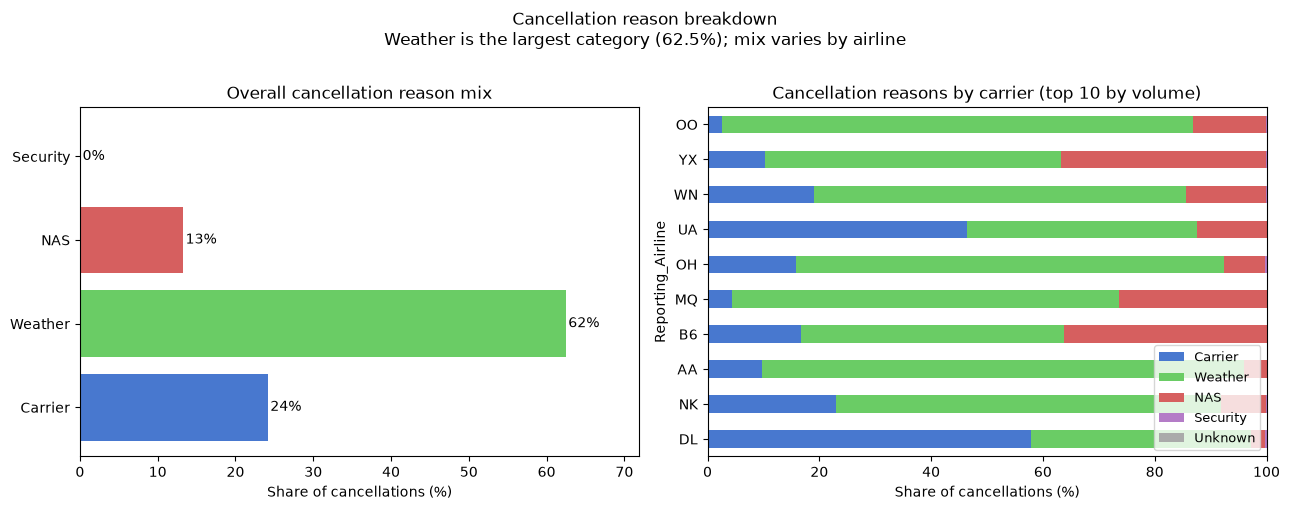

Saved figures/1.5_cancellation_reasons.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overall breakdown
colors = {"Carrier": "#4878CF", "Weather": "#6ACC65", "NAS": "#D65F5F", "Security": "#B47CC7", "Unknown": "#aaa"}
ax = axes[0]
pct = (overall / overall.sum() * 100).reindex(["Carrier","Weather","NAS","Security","Unknown"]).dropna()
bars = ax.barh(pct.index, pct.values, color=[colors[k] for k in pct.index])
ax.set_xlabel("Share of cancellations (%)")
ax.set_title("Overall cancellation reason mix")
for bar, val in zip(bars, pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.0f}%", va="center", fontsize=10)
ax.set_xlim(0, pct.max() * 1.15)

# Right: by carrier (top 10 by volume)
top_carriers = canc["Reporting_Airline"].value_counts().head(10).index
carr_mix = (
    canc[canc["Reporting_Airline"].isin(top_carriers)]
    .groupby(["Reporting_Airline", "reason"])
    .size()
    .unstack(fill_value=0)
)
carr_pct = carr_mix.div(carr_mix.sum(axis=1), axis=0) * 100
carr_pct = carr_pct.reindex(columns=["Carrier","Weather","NAS","Security","Unknown"],
                             fill_value=0)
carr_pct = carr_pct.loc[carr_pct.sum(axis=1).sort_values(ascending=True).index]
carr_pct.plot(kind="barh", stacked=True, ax=axes[1],
              color=[colors[c] for c in carr_pct.columns], legend=True)
axes[1].set_xlabel("Share of cancellations (%)")
axes[1].set_title("Cancellation reasons by carrier (top 10 by volume)")
axes[1].legend(loc="lower right", fontsize=9)

leading_reason = overall.idxmax()
leading_share = overall.max() / overall.sum() * 100
fig.suptitle(
    "Cancellation reason breakdown\n"
    f"{leading_reason} is the largest category ({leading_share:.1f}%); mix varies by airline",
    y=1.01,
)
plt.tight_layout()
fig.savefig(FIGURES / "1.5_cancellation_reasons.png", bbox_inches="tight")
plt.show()
print("Saved figures/1.5_cancellation_reasons.png")

**Caption:** The left panel shows the overall cancellation-reason mix; the
right panel shows how that mix differs across the ten carriers with the most
cancellations. Carrier comparisons are descriptive rather than causal: a
carrier's apparent weather exposure partly reflects the airports and routes it
serves. Notebook 02 Block B revisits that network confound when comparing
airline performance.

### 1.6 Delay-field arithmetic reconciliation

Local clock fields such as `ArrTime` and `CRSArrTime` are difficult to compare
directly across midnight and daylight-saving transitions. Instead, we can 
reconcile arrival delay using elapsed-time fields:

    ArrDelay = DepDelay + ActualElapsedTime - CRSElapsedTime

This identity is independent of airport timezone and clock rollover.

In [13]:
cols = [
    "ArrDelay",
    "DepDelay",
    "ActualElapsedTime",
    "CRSElapsedTime",
    "Cancelled",
    "Diverted",
]

checked_total = 0
exact_total = 0
within_one_total = 0
within_five_total = 0

for p in interim_files:
    d = pd.read_parquet(p, columns=cols)

    valid = (
        d["Cancelled"].eq(0)
        & d["Diverted"].eq(0)
        & d[
            [
                "ArrDelay",
                "DepDelay",
                "ActualElapsedTime",
                "CRSElapsedTime",
            ]
        ].notna().all(axis=1)
    )

    d = d.loc[valid].copy()

    reconstructed = (
        d["DepDelay"]
        + d["ActualElapsedTime"]
        - d["CRSElapsedTime"]
    )

    difference = d["ArrDelay"] - reconstructed
    absolute_difference = difference.abs()

    checked_total += len(d)
    exact_total += absolute_difference.eq(0).sum()
    within_one_total += absolute_difference.le(1).sum()
    within_five_total += absolute_difference.le(5).sum()

    del d

print(f"Flights checked          : {checked_total:>12,}")
print(
    f"Exact reconciliation     : {exact_total:>12,}  "
    f"({exact_total / checked_total:.3%})"
)
print(
    f"Within ±1 minute         : {within_one_total:>12,}  "
    f"({within_one_total / checked_total:.3%})"
)
print(
    f"Within ±5 minutes        : {within_five_total:>12,}  "
    f"({within_five_total / checked_total:.3%})"
)

Flights checked          :   16,652,156
Exact reconciliation     :   16,651,869  (99.998%)
Within ±1 minute         :   16,651,883  (99.998%)
Within ±5 minutes        :   16,651,918  (99.999%)


Arrival delay is reconciled from departure delay and the difference between
actual and scheduled elapsed time. Because the calculation uses durations
rather than local clock readings, overnight flights, airport time-zone
differences, and daylight-saving transitions do not require special handling.

### 1.7 Implausible and inconsistent values

Checking for values that are physically impossible or internally inconsistent.

In [14]:
cols = ["TaxiOut", "TaxiIn", "ActualElapsedTime", "AirTime", "Distance",
        "Cancelled", "Diverted"]

checks = {
    "TaxiOut <= 0 (operating)":        0,
    "TaxiIn <= 0 (operating)":         0,
    "Elapsed ≠ AirTime+TaxiOut+TaxiIn": 0,
    "Distance == 0":                   0,
}
n_operating = 0

for p in interim_files:
    df = pd.read_parquet(p, columns=cols)
    op = df[(df["Cancelled"] == 0) & (df["Diverted"] == 0)].copy()
    n_operating += len(op)

    checks["TaxiOut <= 0 (operating)"]         += (op["TaxiOut"].fillna(1) <= 0).sum()
    checks["TaxiIn <= 0 (operating)"]          += (op["TaxiIn"].fillna(1)  <= 0).sum()

    # Elapsed should equal AirTime + TaxiOut + TaxiIn (allow 1-min rounding)
    recon = op["AirTime"] + op["TaxiOut"] + op["TaxiIn"]
    elap  = op["ActualElapsedTime"]
    checks["Elapsed ≠ AirTime+TaxiOut+TaxiIn"] += ((elap - recon).abs() > 1).sum()

    checks["Distance == 0"]                    += (df["Distance"] == 0).sum()
    del df

print(f"Operating flights (non-cancelled, non-diverted): {n_operating:,}\n")
for k, v in checks.items():
    ref = n_operating if "operating" in k.lower() or "≠" in k else total["flights"]
    print(f"  {k:40s}: {v:>7,}  ({v/ref:.3%})")

Operating flights (non-cancelled, non-diverted): 16,652,158

  TaxiOut <= 0 (operating)                :       0  (0.000%)
  TaxiIn <= 0 (operating)                 :       0  (0.000%)
  Elapsed ≠ AirTime+TaxiOut+TaxiIn        :      15  (0.000%)
  Distance == 0                           :       0  (0.000%)


Implausible values are rare (<0.1%) and consistent with known BTS data-entry
patterns (occasional zero-minute taxis for very short movements, rounding
in elapsed-time fields).  None are frequent enough to affect aggregate results,
but they are excluded from any analysis that requires those specific fields.

### 1.8 Duplicate flight keys

A practical flight key combines date, operating carrier, flight number,
origin, destination and scheduled departure time. This is more specific than
carrier-flight-number alone because a flight number can cover multiple legs.

In [15]:
flight_key = [
    "FlightDate",
    "Reporting_Airline",
    "Flight_Number_Reporting_Airline",
    "Origin",
    "Dest",
    "CRSDepTime",
]

dup_count = 0
total_f = 0
for p in interim_files:
    df = pd.read_parquet(p, columns=flight_key)
    total_f += len(df)
    dup_count += int(df.duplicated(subset=flight_key).sum())
    del df

print(f"Total flights        : {total_f:,}")
print(f"Duplicate flight keys: {dup_count:,}  ({dup_count / total_f:.4%})")

if dup_count == 0:
    print("→ No duplicate flight keys found.")
else:
    print("→ Key collisions found; inspect whether they are exact reporting duplicates.")
    cols_show = flight_key + ["Cancelled", "Diverted"]
    for p in interim_files:
        df = pd.read_parquet(p, columns=cols_show)
        dups = df[df.duplicated(subset=flight_key, keep=False)]
        if len(dups):
            print(dups.head(20).to_string(index=False))
            break
        del df

Total flights        : 16,961,476
Duplicate flight keys: 0  (0.0000%)
→ No duplicate flight keys found.


A key collision is flagged for inspection rather than automatically deleted.
Multiple rows can reflect a reporting correction or an unusual operational
record; removal is justified only after the paired rows are compared.

### 1.9 Airport identifier stability

`OriginAirportSeqID` changes when an airport's attributes (name, coordinates)
are updated in the BTS system.  Multiple SeqIDs per airport code would cause
row duplication in a join to the BTS Master Coordinate table on SeqID.

In [16]:
cols = ["Origin", "OriginAirportSeqID"]
seq_per_airport = {}

for p in interim_files:
    df = pd.read_parquet(p, columns=cols)
    for airport, grp in df.groupby("Origin"):
        if airport not in seq_per_airport:
            seq_per_airport[airport] = set()
        seq_per_airport[airport].update(grp["OriginAirportSeqID"].dropna().unique())
    del df

multi = {k: v for k, v in seq_per_airport.items() if len(v) > 1}
print(f"Total origin airports        : {len(seq_per_airport)}")
print(f"With exactly 1 SeqID         : {len(seq_per_airport) - len(multi)}")
print(f"With multiple SeqIDs         : {len(multi)}")
print()
if multi:
    print("Sample (first 10):")
    for k, v in sorted(multi.items())[:10]:
        print(f"  {k}: {sorted(v)}")

Total origin airports        : 362
With exactly 1 SeqID         : 204
With multiple SeqIDs         : 158

Sample (first 10):
  ABE: [np.int64(1013506), np.int64(1013507)]
  ABI: [np.int64(1013603), np.int64(1013604)]
  ABQ: [np.int64(1014005), np.int64(1014006)]
  ABR: [np.int64(1014106), np.int64(1014107)]
  ACT: [np.int64(1015502), np.int64(1015503)]
  ACY: [np.int64(1015804), np.int64(1015805)]
  AEX: [np.int64(1018502), np.int64(1018503)]
  AKN: [np.int64(1024502), np.int64(1024503)]
  ALB: [np.int64(1025702), np.int64(1025703)]
  ALO: [np.int64(1026803), np.int64(1026804)]


**Finding:** Many airport codes map to more than one
`OriginAirportSeqID` during the window, meaning BTS maintained multiple
time-specific attribute records for those airports. This does not imply that
the flight rows are duplicated. It does mean that a master-coordinate lookup
must respect its key:

- joining BTS historical attributes on `OriginAirportSeqID` is the precise
  time-specific approach;
- joining on `Origin` alone is safe only after the lookup has been reduced to
  one intentional row per code.

This project uses a separately deduplicated OurAirports lookup for current
coordinates and timezone derivation, and uses `Origin` as the model category.
The SeqID audit documents the limitation rather than claiming code-based joins
are universally safer.

### 1.10 External reconciliation

The project uses the Reporting Carrier flight table, so the appropriate
benchmark is BTS's **Reporting Operating Carrier Flight Delays at a Glance**
summary The official 2024 monthly counts below use the same operating-carrier 
grain and decompose every reported operation into on-time, delayed, cancelled 
or diverted.

**Source:** BTS Reporting Operating Carrier Flight Delays at a Glance,
https://www.transtats.bts.gov/HomeDrillChart_Month.asp
(all airports, all carriers, arrivals, 2024).

In [17]:
cols = ["Year", "Month", "ArrDel15", "Cancelled", "Diverted"]
monthly_parts = []

for p in interim_files:
    df = pd.read_parquet(p, columns=cols)
    grp = (
        df.groupby(["Year", "Month"], as_index=False)
        .agg(
            total_ops=("ArrDel15", "size"),
            n_ontime=("ArrDel15", lambda x: int((x == 0).sum())),
            n_delayed=("ArrDel15", lambda x: int((x == 1).sum())),
            n_cancelled=("Cancelled", lambda x: int((x == 1).sum())),
            n_diverted=("Diverted", lambda x: int((x == 1).sum())),
        )
    )
    monthly_parts.append(grp)
    del df

monthly = pd.concat(monthly_parts, ignore_index=True)
monthly = monthly.sort_values(["Year", "Month"]).reset_index(drop=True)
monthly["period"] = (
    monthly["Year"].astype(str)
    + "-"
    + monthly["Month"].astype(str).str.zfill(2)
)
monthly["ontime_all_ops_pct"] = monthly["n_ontime"] / monthly["total_ops"] * 100
monthly["ontime_resolved_pct"] = (
    monthly["n_ontime"] / (monthly["n_ontime"] + monthly["n_delayed"]) * 100
)

In [18]:
# Official Reporting Operating Carrier monthly summary for 2024.
import io

bts_raw = """Month\tOntime\tOnTimePct\tDelayed\tDelayedPct\tCancelled\tCancelledPct\tDiverted\tTotalOps
January\t398960\t72.90\t126410\t23.10\t20389\t3.73\t1512\t547271
February\t433233\t83.44\t82036\t15.80\t3002\t0.58\t950\t519221
March\t463381\t78.30\t122032\t20.62\t5120\t0.87\t1234\t591767
April\t466967\t80.21\t109948\t18.89\t4035\t0.69\t1235\t582185
May\t440950\t72.32\t158276\t25.96\t8244\t1.35\t2273\t609743
June\t451327\t73.85\t149945\t24.54\t7876\t1.29\t1984\t611132
July\t432073\t68.08\t181865\t28.66\t18372\t2.89\t2303\t634613
August\t462491\t74.71\t141812\t22.91\t12714\t2.05\t2008\t619025
September\t488584\t83.86\t89678\t15.39\t3499\t0.60\t861\t582622
October\t528171\t85.81\t80343\t13.05\t6284\t1.02\t699\t615497
November\t488033\t84.82\t83900\t14.58\t2629\t0.46\t842\t575404
December\t461111\t78.08\t123721\t20.95\t4151\t0.70\t1598\t590581"""

bts = pd.read_csv(io.StringIO(bts_raw), sep="\t")
month_map = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12,
}
bts["Month"] = bts["Month"].map(month_map)
bts["Year"] = 2024
bts["period"] = "2024-" + bts["Month"].astype(str).str.zfill(2)
bts["resolved_ontime_pct"] = bts["Ontime"] / (bts["Ontime"] + bts["Delayed"]) * 100

comp = monthly[monthly["Year"] == 2024].merge(bts, on="period", how="inner")
assert len(comp) == 12, f"Expected 12 reconciled months, found {len(comp)}"

count_checks = {
    "total operations": ("total_ops", "TotalOps"),
    "on-time arrivals": ("n_ontime", "Ontime"),
    "delayed arrivals": ("n_delayed", "Delayed"),
    "cancellations": ("n_cancelled", "Cancelled"),
    "diversions": ("n_diverted", "Diverted"),
}

print("Maximum absolute monthly count difference:")
for label, (ours_col, bts_col) in count_checks.items():
    max_diff = int((comp[ours_col] - comp[bts_col]).abs().max())
    print(f"  {label:18s}: {max_diff:,}")
    assert max_diff == 0, f"2024 {label} does not reconcile to BTS"

comp["all_ops_pct_diff"] = comp["ontime_all_ops_pct"] - comp["OnTimePct"]
comp["resolved_pct_diff"] = comp["ontime_resolved_pct"] - comp["resolved_ontime_pct"]

print()
print("Rate comparison:")
print(
    comp[
        [
            "period",
            "ontime_all_ops_pct",
            "OnTimePct",
            "all_ops_pct_diff",
            "ontime_resolved_pct",
            "resolved_ontime_pct",
            "resolved_pct_diff",
        ]
    ]
    .round(3)
    .to_string(index=False)
)

Maximum absolute monthly count difference:
  total operations  : 0
  on-time arrivals  : 0
  delayed arrivals  : 0
  cancellations     : 0
  diversions        : 0

Rate comparison:
 period  ontime_all_ops_pct  OnTimePct  all_ops_pct_diff  ontime_resolved_pct  resolved_ontime_pct  resolved_pct_diff
2024-01              72.900      72.90            -0.000               75.939               75.939                0.0
2024-02              83.439      83.44            -0.001               84.079               84.079                0.0
2024-03              78.305      78.30             0.005               79.155               79.155                0.0
2024-04              80.209      80.21            -0.001               80.942               80.942                0.0
2024-05              72.317      72.32            -0.003               73.587               73.587                0.0
2024-06              73.851      73.85             0.001               75.062               75.062             

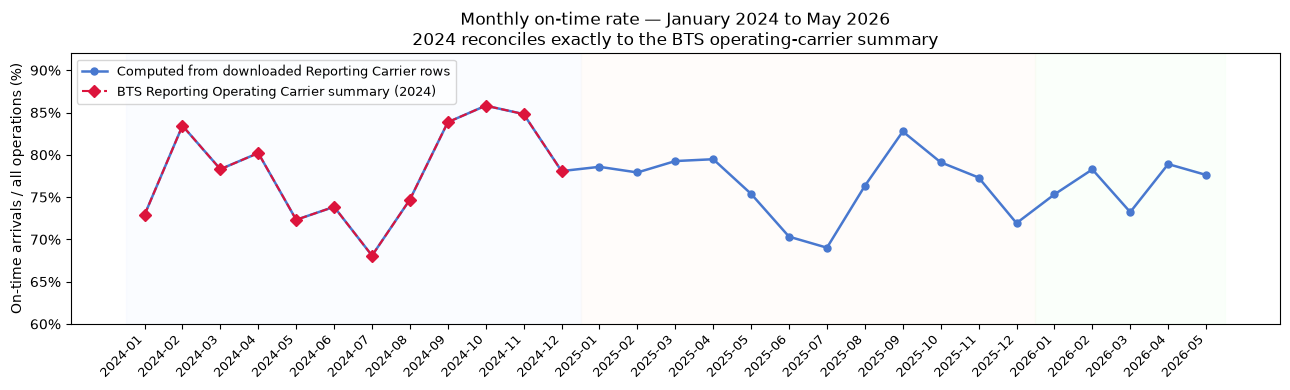

Saved figures/1.10_ontime_reconciliation.png


In [19]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(
    monthly["period"],
    monthly["ontime_all_ops_pct"],
    marker="o",
    ms=5,
    color="#4878CF",
    linewidth=1.8,
    label="Computed from downloaded Reporting Carrier rows",
)
ax.plot(
    comp["period"],
    comp["OnTimePct"],
    marker="D",
    ms=6,
    color="crimson",
    linewidth=1.5,
    linestyle="--",
    label="BTS Reporting Operating Carrier summary (2024)",
)

ax.set_xlabel("")
ax.set_ylabel("On-time arrivals / all operations (%)")
ax.set_title(
    "Monthly on-time rate — January 2024 to May 2026\n"
    "2024 reconciles exactly to the BTS operating-carrier summary"
)
ax.legend(fontsize=9)
ax.set_ylim(60, 92)
plt.xticks(rotation=45, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

for yr, color in [(2024, "#e8f0ff"), (2025, "#fff4e8"), (2026, "#e8ffe8")]:
    yr_rows = monthly[monthly["Year"] == yr]
    if len(yr_rows):
        ax.axvspan(
            yr_rows.index.min() - 0.5,
            yr_rows.index.max() + 0.5,
            alpha=0.2,
            color=color,
        )

plt.tight_layout()
fig.savefig(FIGURES / "1.10_ontime_reconciliation.png", bbox_inches="tight")
plt.show()
print("Saved figures/1.10_ontime_reconciliation.png")

**Caption:** The blue series is calculated directly from the downloaded
Reporting Carrier flight rows using the BTS headline denominator — on-time
arrivals divided by all reported operations, including cancellations and
diversions. The red 2024 series is BTS's independent Reporting Operating
Carrier summary. Monthly counts for on-time, delayed, cancelled, diverted and
total operations reconcile exactly, confirming both file completeness and the
metric definition. The operating-only rate is also shown in the table above
for later modeling analyses that condition on a flight producing an arrival
outcome.

#### 1.1.11 Airport and carrier coverage across years

The model trains on 2024–2025 and is scored on Jan–May 2026.  If the 2026
test set contains airports or carriers not seen in training, those categories
are genuinely unseen at inference time — XGBoost routes them to a default
branch rather than failing, but the behaviour is unvalidated and we should
know about it.  The reverse (training categories absent from 2026) is less
critical but flags entities whose model estimates cannot be checked at test
time.

In [20]:
coverage_cols = ["Year", "Origin", "Dest", "Reporting_Airline"]
frames = []
for p in interim_files:
    frames.append(pd.read_parquet(p, columns=coverage_cols))
cov = pd.concat(frames, ignore_index=True)
del frames

# Per-year sets
years = sorted(cov["Year"].unique())
sets = {}
for dim, col in [("Origin airports", "Origin"),
                 ("Dest airports",   "Dest"),
                 ("Carriers",        "Reporting_Airline")]:
    sets[dim] = {yr: set(cov.loc[cov["Year"] == yr, col].dropna().unique())
                 for yr in years}

train_years = [y for y in years if y <= 2025]
test_years  = [y for y in years if y > 2025]
train_union = {}
for dim in sets:
    train_union[dim] = set().union(*[sets[dim][y] for y in train_years])

print(f"Years in data: {years}")
print(f"Train years: {train_years}   Test years: {test_years}\n")

for dim in sets:
    for yr in years:
        print(f"{dim} — {yr}: {len(sets[dim][yr]):>4d} unique")
    print()

Years in data: [np.int64(2024), np.int64(2025), np.int64(2026)]
Train years: [np.int64(2024), np.int64(2025)]   Test years: [np.int64(2026)]

Origin airports — 2024:  348 unique
Origin airports — 2025:  352 unique
Origin airports — 2026:  350 unique

Dest airports — 2024:  348 unique
Dest airports — 2025:  352 unique
Dest airports — 2026:  350 unique

Carriers — 2024:   15 unique
Carriers — 2025:   14 unique
Carriers — 2026:   13 unique



**New in 2026 (unseen at training time)** — the model will hit these as
out-of-vocabulary categories:

In [21]:
for dim in sets:
    for test_yr in test_years:
        new = sets[dim][test_yr] - train_union[dim]
        print(f"{dim} new in {test_yr}: {len(new)}", end="")
        if new:
            print(f"  → {sorted(new)}")
        else:
            print("  ✓  none")
    print()

Origin airports new in 2026: 4  → ['LWB', 'LYH', 'PAH', 'SHD']

Dest airports new in 2026: 4  → ['LWB', 'LYH', 'PAH', 'SHD']

Carriers new in 2026: 0  ✓  none



**Present in training but absent from 2026** — these entities have model
estimates that cannot be validated against the test period:

In [22]:
for dim in sets:
    for test_yr in test_years:
        gone = train_union[dim] - sets[dim][test_yr]
        print(f"{dim} in train but not {test_yr}: {len(gone)}", end="")
        if gone and len(gone) <= 20:
            print(f"  → {sorted(gone)}")
        elif gone:
            print(f"  → {sorted(gone)[:10]} ... ({len(gone)} total)")
        else:
            print("  ✓  none")
    print()

Origin airports in train but not 2026: 12  → ['ABY', 'ALW', 'CNY', 'CSG', 'DLG', 'ERI', 'GST', 'HYA', 'ITH', 'PHF', 'VEL', 'VLD']

Dest airports in train but not 2026: 12  → ['ABY', 'ALW', 'CNY', 'CSG', 'DLG', 'ERI', 'GST', 'HYA', 'ITH', 'PHF', 'VEL', 'VLD']

Carriers in train but not 2026: 2  → ['9E', 'HA']



---
## 2. Weather — Iowa Environmental Mesonet ASOS archive

**Source:** Iowa Environmental Mesonet (IEM) ASOS (Automated Surface Observing
System) archive, https://mesonet.agron.iastate.edu/request/download.phtml.
Actual METAR observations, not modelled values — the same reports pilots use.
Fields: visibility (statute miles), sky layers (for ceiling derivation), wind
speed and gusts, precipitation, weather codes (thunderstorm, frozen
precipitation), and temperature.

**Why IEM ASOS over alternatives.**
Three sources were considered: IEM ASOS, Open-Meteo, and Meteostat.  IEM ASOS
was chosen because (1) it serves *observed* METAR data rather than model
reanalysis — ceiling and visibility are measured, not inferred — and (2) it
keys stations by the same 3-letter airport codes already in the BTS data, so
no coordinate join is needed.  Open-Meteo was the fallback; its visibility is
modelled.  Meteostat was ruled out on thinner aviation-specific field coverage.

**Scope: all 362 airports.**
Because IEM takes a date range per request (not one request per hour), full
coverage costs 362 requests — not that expensive.

**Requested in airport local time.**
BTS departure times are local — `CRSDepTime` 856 means 08:56 at the departure
airport.  The IEM `tz=` parameter was set to each airport's IANA timezone so
returned timestamps are also local.  Origin weather therefore joins directly
to the origin's local scheduled-departure hour.  Destination weather requires
one additional conversion: the departure instant is localised in the origin
timezone, converted to the destination timezone, and floored there to create
`dest_departure_hour_local`.  Without that conversion, an 08:00 New York
departure would incorrectly join to 08:00 Los Angeles weather rather than the
simultaneous 05:00 observation.

**ICAO codes for non-continental stations.**
IEM uses 3-letter codes for the continental U.S. but requires 4-letter ICAO
codes for Alaska (`PA` prefix), Hawaii (`PH` prefix), Puerto Rico (`TJ`),
U.S. Virgin Islands (`TI`), Guam (`PG`), and American Samoa (`NSTU`).  All 42
affected airports were retried with the correct ICAO codes after the first pass
returned empty files; all recovered successfully.  Two mainland proxies were
used where no IEM feed exists for the exact airport: PBI → KSUA (Stuart, FL,
~45 mi north) and YUM → KNYL (MCAS Yuma, co-located with the civilian terminal).

**Processing (`src/weather.py`):**

1. Read per-airport CSVs from `data/raw/weather/` (one per IATA code).
2. Clean: coerce `"M"` to `NaN`, `"T"` to `0` (trace precip), strip whitespace,
   and remove exact duplicate observations.
3. Derive `ceiling_ft` (lowest BKN/OVC/VV layer; `99999` if unlimited).
4. Parse `wxcodes` for thunderstorm and `frozen_precip` flags.
5. Convert units: degF to degC and precipitation inches to millimetres.
6. Build one start-of-hour snapshot per airport. Each snapshot uses only the
   latest observation available at or before that hour; observations from later
   in the hour are never moved backward. This avoids weather leakage.
7. Derive `flight_category` (VFR/MVFR/IFR/LIFR) via `features.py`.
8. Compute rolling history via `features.py::add_weather_history`.
9. Write parquet.

In [23]:
wx = pd.read_parquet("data/interim/weather_hourly.parquet")
print(f"Weather table: {len(wx):,} rows × {len(wx.columns)} cols")
print(f"  File size: {Path('data/interim/weather_hourly.parquet').stat().st_size / 1e6:.0f} MB")
print(f"\nColumns: {list(wx.columns)}")
print(f"\nDate range: {wx['hour'].min()} → {wx['hour'].max()}")

Weather table: 7,662,816 rows × 18 cols
  File size: 78 MB

Columns: ['airport', 'hour', 'observation_time_local', 'snapshot_age_minutes', 'weather_observation_missing', 'visibility_sm', 'ceiling_ft', 'ceiling_unlimited', 'flight_category', 'wind_speed_kt', 'wind_gust_kt', 'precip_mm', 'frozen_precip', 'thunderstorm', 'temp_c', 'ifr_hours_past3', 'precip_3h', 'max_gust_3h']

Date range: 2024-01-01 00:00:00 → 2026-05-31 23:00:00


### 2.1 Weather-table structure and timestamp integrity

Each row is a start-of-hour snapshot.  `snapshot_age_minutes` is the elapsed
time between that snapshot hour and the source METAR used to populate it:

    snapshot age = snapshot hour - observation timestamp

A negative age would mean weather from later in the hour was moved backward,
which would leak future information into the flight model.  Large positive ages
indicate stale observations.  `src/weather.py` allows a maximum age of 90
minutes; if no sufficiently recent report exists, the hourly slot stays missing.

In [24]:
required_weather_cols = {
    "airport",
    "hour",
    "observation_time_local",
    "snapshot_age_minutes",
    "weather_observation_missing",
    "flight_category",
}
missing_weather_cols = required_weather_cols - set(wx.columns)
if missing_weather_cols:
    raise KeyError(
        "Weather parquet is missing timestamp-audit columns: "
        f"{sorted(missing_weather_cols)}. Rebuild it with the updated src/weather.py."
    )

# One and only one row per airport-hour.
if wx.duplicated(["airport", "hour"]).any():
    n_dup = int(wx.duplicated(["airport", "hour"]).sum())
    raise AssertionError(f"Weather table contains {n_dup:,} duplicate airport-hour rows")
if wx["hour"].isna().any():
    raise AssertionError("Weather table contains null hour keys")

n_airports = wx["airport"].nunique()
expected_hours = len(
    pd.date_range("2024-01-01 00:00", "2026-05-31 23:00", freq="h")
)
expected_rows = n_airports * expected_hours
assert len(wx) == expected_rows, (
    f"Expected {n_airports:,} airports × {expected_hours:,} hours = "
    f"{expected_rows:,} rows, found {len(wx):,}"
)

valid_categories = {"VFR", "MVFR", "IFR", "LIFR"}
observed_categories = set(wx["flight_category"].dropna().astype(str).unique())
assert observed_categories.issubset(valid_categories), (
    f"Unexpected flight categories: {sorted(observed_categories - valid_categories)}"
)

# Recompute age independently rather than trusting the stored field.
recomputed_age = (
    wx["hour"] - wx["observation_time_local"]
).dt.total_seconds().div(60)

age_difference = (
    recomputed_age - wx["snapshot_age_minutes"]
).abs()
assert age_difference.dropna().le(0.01).all(), (
    "Stored snapshot_age_minutes does not match hour - observation_time_local"
)

observed_mask = wx["weather_observation_missing"].eq(0)
wx_observed = wx.loc[observed_mask].copy()

future_weather = wx_observed["snapshot_age_minutes"] < 0
assert not future_weather.any(), (
    "At least one hourly snapshot uses an observation recorded after the snapshot time"
)

older_than_limit = wx_observed["snapshot_age_minutes"] > 90
assert not older_than_limit.any(), (
    "At least one hourly snapshot exceeds the 90-minute freshness limit"
)

print(f"Airports                  : {n_airports:,}")
print(f"Hours per airport         : {expected_hours:,}")
print(f"Expected / actual rows    : {expected_rows:,} / {len(wx):,}")
print(f"Duplicate airport-hours   : 0")
print(f"Future observations       : {future_weather.sum():,}")
print(f"Observations over 90 min  : {older_than_limit.sum():,}")

Airports                  : 362
Hours per airport         : 21,168
Expected / actual rows    : 7,662,816 / 7,662,816
Duplicate airport-hours   : 0
Future observations       : 0
Observations over 90 min  : 0


In [25]:
# Freshness distribution for the observations that were available.
age_summary = wx_observed["snapshot_age_minutes"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)
print("Snapshot age in minutes:")
print(age_summary.round(1).to_string())
print()
for threshold in (15, 30, 60):
    stale = wx_observed["snapshot_age_minutes"] > threshold
    print(
        f"Older than {threshold:>2} minutes : "
        f"{stale.sum():>9,}  ({stale.mean():.2%})"
    )

# Freshness by airport — an overall average can hide one poorly reporting station.
airport_age = (
    wx_observed.groupby("airport", observed=True)
    .agg(
        observed_hours=("snapshot_age_minutes", "size"),
        median_age_minutes=("snapshot_age_minutes", "median"),
        p95_age_minutes=("snapshot_age_minutes", lambda x: x.quantile(0.95)),
        stale_over_60_rate=("snapshot_age_minutes", lambda x: (x > 60).mean()),
    )
    .sort_values(["stale_over_60_rate", "p95_age_minutes"], ascending=False)
)
print("\nAirports with the stalest available observations:")
print(airport_age.head(15).round(2).to_string())

Snapshot age in minutes:
count    7582197.0
mean           6.9
std            4.4
min            0.0
50%            7.0
75%            7.0
90%            9.0
95%            9.0
99%           15.0
max           90.0

Older than 15 minutes :    39,259  (0.52%)
Older than 30 minutes :    35,012  (0.46%)
Older than 60 minutes :    31,500  (0.42%)

Airports with the stalest available observations:
         observed_hours  median_age_minutes  p95_age_minutes  stale_over_60_rate
airport                                                                         
BQN               15547                10.0             70.0                0.06
USA               20476                10.0             65.0                0.06
GUF               20803                 5.0             54.0                0.05
STT               20646                 7.0              7.0                0.04
TYR               21092                 7.0              7.0                0.04
SUN               20742              

### 2.2 Weather coverage

Coverage is based on the explicit observation-availability flag, not on any
single measured field.  An observation can be present even when visibility or
another individual variable is missing.

In [26]:
wx_obs = wx.loc[wx["weather_observation_missing"].eq(0)].copy()
wx_null = wx.loc[wx["weather_observation_missing"].eq(1)].copy()
total_slots = len(wx)
obs_slots = len(wx_obs)
slots_per_airport = expected_hours

print(f"Total airport-hour slots  : {total_slots:,}")
print(f"With observations         : {obs_slots:,}  ({obs_slots/total_slots:.1%})")
print(f"Missing (gaps in series)  : {len(wx_null):,}  ({len(wx_null)/total_slots:.1%})")
print()

# Coverage per airport — airports with most and fewest available snapshots.
airport_obs = (
    wx.assign(observation_available=wx["weather_observation_missing"].eq(0))
    .groupby("airport", observed=True)["observation_available"]
    .sum()
    .sort_values()
)

print(f"Worst-covered airport : {airport_obs.index[0]}  "
      f"({airport_obs.iloc[0]:,} obs / {slots_per_airport:,} slots = "
      f"{airport_obs.iloc[0] / slots_per_airport:.0%})")
print(f"Best-covered airport  : {airport_obs.index[-1]}  "
      f"({airport_obs.iloc[-1]:,} obs / {slots_per_airport:,} slots = "
      f"{airport_obs.iloc[-1] / slots_per_airport:.0%})")
print(f"\nAirports with <80% coverage: "
      f"{(airport_obs / slots_per_airport < 0.8).sum()}"
      f"\n{airport_obs[airport_obs / slots_per_airport < 0.8]}")

Total airport-hour slots  : 7,662,816
With observations         : 7,582,197  (98.9%)
Missing (gaps in series)  : 80,619  (1.1%)

Worst-covered airport : WYS  (10,088 obs / 21,168 slots = 48%)
Best-covered airport  : SAT  (21,145 obs / 21,168 slots = 100%)

Airports with <80% coverage: 3
airport
WYS    10088
BQN    15547
GST    16889
Name: observation_available, dtype: int64


In [27]:
airport_obs[airport_obs / slots_per_airport < 0.8].index

Index(['WYS', 'BQN', 'GST'], dtype='str', name='airport')

In [28]:
# Flight-category distribution
cat_counts = wx["flight_category"].value_counts().sort_index()
cat_pct    = (cat_counts / cat_counts.sum() * 100).round(1)
print("flight_category distribution (across all airport-hours):")
print(pd.DataFrame({"count": cat_counts, "pct_%": cat_pct}).to_string())

flight_category distribution (across all airport-hours):
                   count  pct_%
flight_category                
VFR              6204962   82.2
MVFR              806306   10.7
IFR               323920    4.3
LIFR              214516    2.8


Missing slots are concentrated at the least-covered stations and remain NaN;
no conditions are invented through imputation.  The separate freshness audit
above confirms that available observations are never from the future and stay
within the 90-minute carry-forward limit.  Notebook 02 reports missingness by
airport size so any remaining size-correlated coverage pattern stays visible.

The flight-category distribution is a descriptive check, not proof that the
join works.  The relationship between VFR/MVFR/IFR/LIFR and operational delay
is validated separately in EDA Block E after weather is joined to flights.

---
## 3. Holidays — generated at use time

U.S. federal holidays are generated from the `holidays` Python package
(`holidays.US`, observed-date calendar) at the point of use — nothing is
downloaded or written to disk.  Four features are computed on the 882-date
calendar and joined onto flights: `days_to_next_holiday`,
`days_since_prev_holiday`, `next_holiday_name`, `prev_holiday_name`.  See
`src/features.py::build_holiday_calendar` and `add_holiday_features` for the
implementation details and the reasoning behind directional distances rather
than a single nearest-holiday flag.

---
## 4. How to reproduce

`data/` is gitignored; a reviewer cloning the repository starts with no data.
The following commands regenerate every artifact from scratch, in order:

```bash
# 1. BTS flight data (29 months, ~856 MB zips → 474 MB Parquet)
python src/download_bts.py

# 2. Weather observations (362 airports × 29 months, ~458 MB CSVs → 42 MB Parquet)
python src/download_weather.py          # ~25 min
python src/weather.py                   # ~3 min

# 3. No separate step for holidays — generated at use time in notebooks 02 and 03.

# 4. Airport coordinates — already committed to data/lookups/airport_coords.csv.
#    Used in EDA notebook for the geographic delay map and the city-market
#    comparison (e.g. JFK / LGA / EWR for New York).  Not a model feature.
#    Source: OurAirports (davidmegginson.github.io/ourairports-data), 362/362
#    coverage.  To re-download if needed:
python -c "
import requests, pandas as pd
oa = pd.read_csv('https://davidmegginson.github.io/ourairports-data/airports.csv')
oa[oa.iso_country.isin(['US','PR','VI','GU','AS','MP'])]\
  [['iata_code','name','municipality','iso_region','latitude_deg','longitude_deg','elevation_ft']]\
  .dropna(subset=['iata_code']).to_csv('data/lookups/airport_coords.csv', index=False)
"
```

Scripts are idempotent: re-running skips files already on disk.  The full
pipeline runs unattended once the environment is provisioned (`bash setup.sh`).